In [2]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [4]:
# Data Preparation
df = pd.read_csv("q2_customers.csv")

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Why scaling is essential:

K-Means uses distance (Euclidean distance)
Features like annual_spend may have much larger values than visits_per_month
Without scaling:
Large-scale features dominate clustering 
Scaling ensures:
All features contribute equally

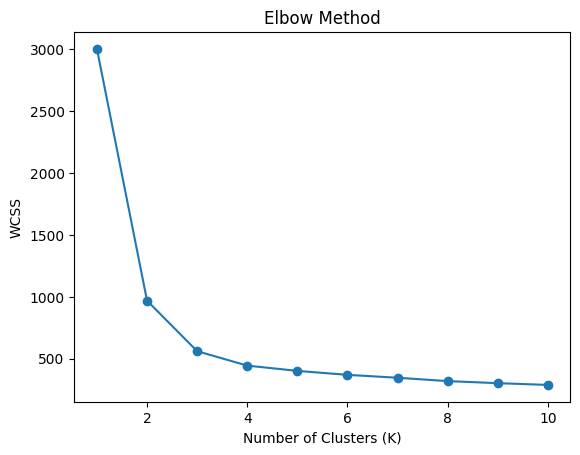

In [6]:
# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Look for the “bend” in the curve
If elbow at K = 3, choose 3 clusters
Reason:
After that point → diminishing returns

In [7]:
# K means Clustering
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [8]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0 → High spend, frequent visitors → Premium customers
Cluster 1 → Low spend, low visits → Occasional customers
Cluster 2 → Moderate spend → Regular customers

In [9]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [10]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df.columns[:-1]
)

loadings

,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


PC1 → Dominant features with highest weights
Example:
If annual_spend & basket_size high → PC1 = spending behavior
PC2 → Second pattern
e.g., visit frequency vs recency

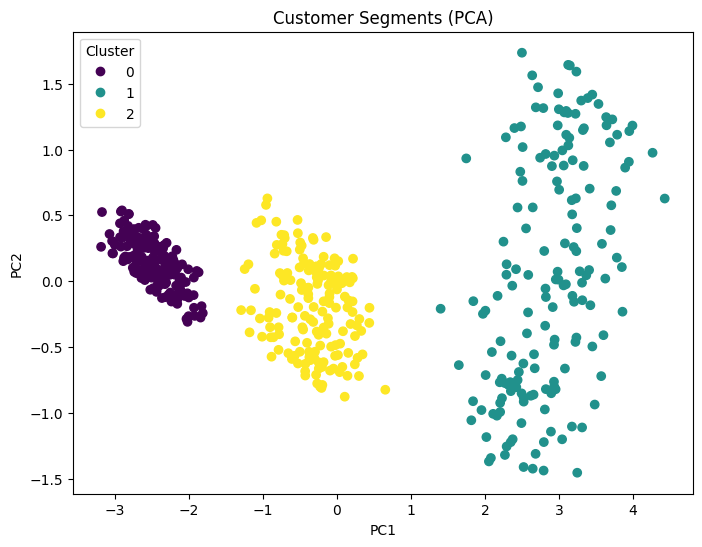

In [12]:
# Cluster Visualization
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA)")

plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()